In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [2]:
subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']

In [3]:
experiment = 'ValueCourier'
data = cml.get_data_index(kind = 'ltp')
data = data[(data['experiment']==experiment)].sort_values('session').reset_index()

full_evs = None
for i, row in data.iterrows():
    # intialize data reader, load words events and buffered eeg epochs
    r = cml.CMLReader(subject=row['subject'], experiment=row['experiment'], session=row['session'])
    evs = r.load('task_events')
    full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
full_evs = full_evs.query('subject in @subjects')
full_evs

,eegoffset,actualvalue,compensation,correctPointingDirection,eegfile,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,itemvalue,montage,msoffset,mstime,multiplier,numingroupchosen,phase,playerrotY,presX,presZ,primacybuf,protocol,recalled,recencybuf,rectime,serialpos,session,store,storeX,storeZ,storepointtype,subject,submittedPointingDirection,trial,type,valuerecall
258,23440,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761665861795,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0000,-999.000000,,LTP606,-999,0,store mappings,-999
259,31922,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-1,-999,0,-1,1761665865937,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0000,-999.000000,,LTP606,-999,0,VIDEO_START,-999
260,468068,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-1,-999,0,-1,1761666078916,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0000,-999.000000,,LTP606,-999,0,VIDEO_STOP,-999
261,646089,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761666165847,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0000,-999.000000,,LTP606,-999,0,SESS_START,-999
262,646183,-999.0,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1761666165893,0.846154,4,1,-999.0,-4.949219,10.500000,2,ltp,-999,3,-999,-999,0,-999,-999.0000,-999.000000,,LTP606,-999,0,TL_START,-999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7856,5428009,-999.0,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,0,ORCHIDS,148,-999,0,20,1763669394892,-999.000000,-999,1,-999.0,-3.544922,9.984375,-999,ltp,-999,-999,3019,4,5,florist,140.7500,60.593750,,LTP606,-999,5,REC_WORD,-999
7857,5460438,-999.0,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,0,HAMSTER,105,-999,0,20,1763669410727,-999.000000,-999,1,-999.0,-3.544922,9.984375,-999,ltp,-999,-999,18854,8,5,pet_store,93.5625,-7.761719,,LTP606,-999,5,REC_WORD,-999
7858,5575424,-999.0,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1763669466874,-999.000000,-999,1,-999.0,-3.544922,9.984375,-999,ltp,-999,-999,-999,-999,5,-999,-999.0000,-999.000000,,LTP606,-999,5,SESS_START,-999
7859,5575426,-999.0,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,-999,-999,-999,-999,0,-1,1763669466875,-999.000000,-999,1,-999.0,-3.544922,9.984375,-999,ltp,-999,-999,-999,-999,5,-999,-999.0000,-999.000000,,LTP606,-999,5,REC_STOP,-999


In [4]:
with open("all_items.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

full_evs["itemno"] = full_evs["item"].map(pool_map)

## Behavioral

In [5]:
# Overall recall probability

pres = full_evs.type=='WORD'
recall_by_sub = full_evs[pres].groupby('subject')\
    .agg({'recalled':'mean'})\
    .rename(columns={"recalled":"Recall_Probability"}
)
recall_by_sub = recall_by_sub.reset_index()
recall_by_sub = recall_by_sub.sort_values(by="Recall_Probability", ascending=True)
sub_recall = recall_by_sub.subject.values
recall_by_sub

,subject,Recall_Probability
0,LTP606,0.241830
2,LTP609,0.322424
3,LTP610,0.348148
1,LTP607,0.505185
4,LTP612,0.813333


In [6]:
print(f"Mean = {recall_by_sub['Recall_Probability'].mean()}, SD = {recall_by_sub['Recall_Probability'].std()}")

Mean = 0.44618419489007727, SD = 0.22636685339663212


In [7]:
# SPC

spc_df = full_evs.query("type=='WORD'").groupby(
    ['subject', 'session', 'serialpos']
).agg({'recalled':np.nanmean}).reset_index()

avg_spc_df = spc_df.groupby(["subject","serialpos"]).agg({"recalled":"mean"}).reset_index()

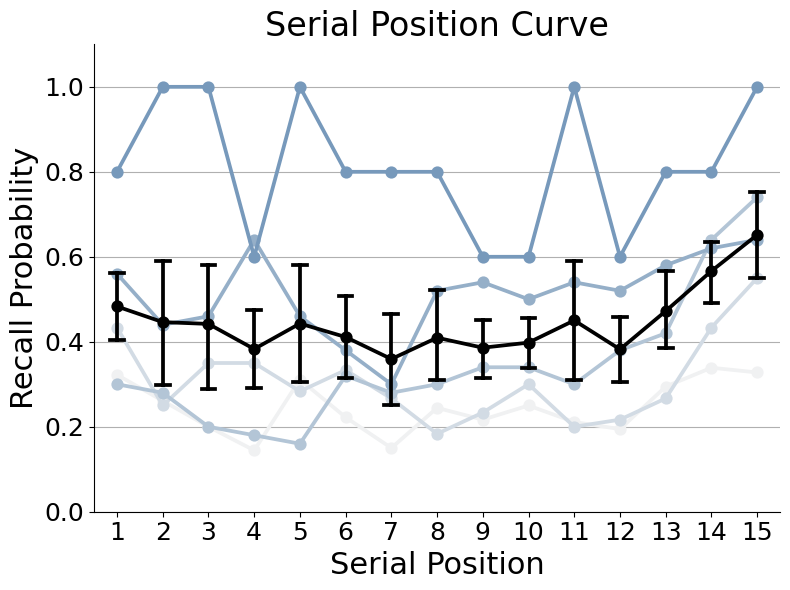

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = avg_spc_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='recalled', ci=None, ax=ax, color=colors[i])
    
spc = sns.pointplot(data=avg_spc_df, x='serialpos', y='recalled', ci=68, capsize=.3, ax=ax, color="k")

plt.title('Serial Position Curve', fontsize=24)
plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.1)
spc.yaxis.grid()
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
plt.show()

In [9]:
# Probability of first recall

recword = full_evs.query('type=="REC_WORD"')
recword['pos'] = recword.groupby(['subject', 'session', 'trial']).cumcount()
first_recall_df = recword.query('pos == 0 and serialpos >= 0')
first_recall_df = first_recall_df.groupby(
    ['subject', 'serialpos']).agg(
    {'recalled': 'count'}).unstack(fill_value=0).stack().reset_index()
first_recall_df['n_lists'] = first_recall_df.groupby(['subject'])['recalled'].transform('sum')
first_recall_df['prob'] = first_recall_df['recalled'] / first_recall_df['n_lists']

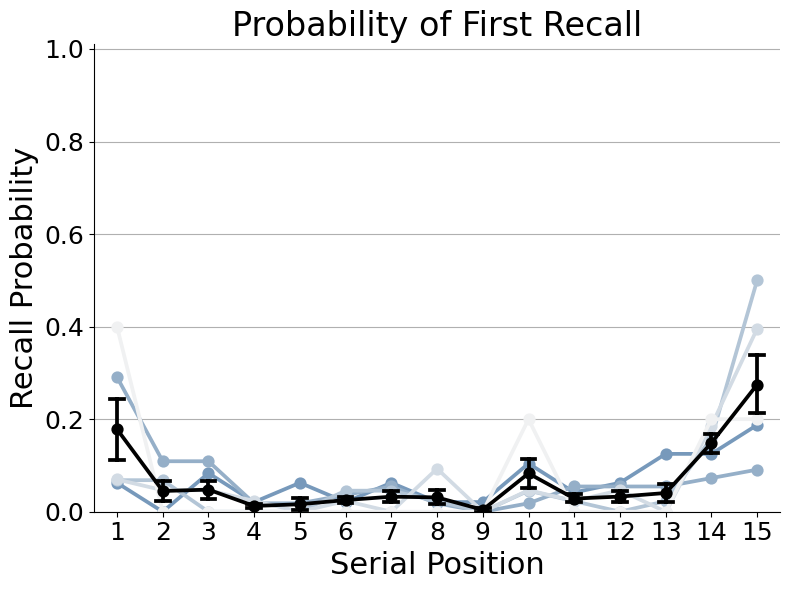

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_df = first_recall_df.query('subject == @sub')
    sub_spc = sns.pointplot(data=sub_df, x='serialpos', y='prob', ci=None, ax=ax, color=colors[len(colors)-i-1])

spc = sns.pointplot(data=first_recall_df, x='serialpos', y='prob', ci=68, capsize=.3, ax=ax, color="k")

plt.title('Probability of First Recall', fontsize=24)
plt.xlabel('Serial Position', fontsize=22)
plt.ylabel('Recall Probability', fontsize=22)
plt.tick_params(labelsize=18)
plt.ylim(0, 1.01)
plt.tight_layout()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
spc.yaxis.grid()
plt.show()

In [11]:
# Lag CRP

rec_word_types_all = ['REC_WORD', 'REC_WORD_VV']
present_types = set(full_evs['type'].unique())
present_rec_types = [t for t in rec_word_types_all if t in present_types]

need_types = ['WORD'] + present_rec_types
clean_evs = full_evs[full_evs['type'].isin(need_types)].copy()

for t in present_rec_types:
    if t != 'REC_WORD':
        clean_evs.loc[clean_evs['type'] == t, 'type'] = 'REC_WORD'

is_word = clean_evs['type'].eq('WORD')
is_rec  = clean_evs['type'].eq('REC_WORD')

temporal_evs = clean_evs[~(is_word & clean_evs['itemno'].isna())].copy()
temporal_evs.loc[is_rec, 'itemno'] = temporal_evs.loc[is_rec, 'itemno'].fillna(0)

temporal_evs['itemno'] = temporal_evs['itemno'].astype('int64')
temporal_evs

,eegoffset,actualvalue,compensation,correctPointingDirection,eegfile,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,itemvalue,montage,msoffset,mstime,multiplier,numingroupchosen,phase,playerrotY,presX,presZ,primacybuf,protocol,recalled,recencybuf,rectime,serialpos,session,store,storeX,storeZ,storepointtype,subject,submittedPointingDirection,trial,type,valuerecall
326,4708671,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,JEANS,115,10,0,-1,1761668149687,0.846154,4,1,84.570000,56.968750,81.750000,2,ltp,1,3,-999,1,0,clothing_store,56.718750,77.937500,Temporal,LTP606,-999,0,WORD,15
328,4841846,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,WATER_GUN,232,13,0,-1,1761668214719,0.846154,4,1,103.199997,-33.375000,-83.812500,2,ltp,1,3,-999,2,0,toy_store,-29.187500,-93.875000,Temporal,LTP606,-999,0,WORD,15
329,4888199,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,LIGHT,122,22,0,-1,1761668237354,0.846154,4,1,206.360001,22.296875,-51.375000,2,ltp,0,3,-999,3,0,bike_shop,18.671875,-51.718750,Temporal,LTP606,-999,0,WORD,15
331,5016054,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,PEARLS,154,22,0,-1,1761668299788,0.846154,4,1,2.900000,-42.531250,61.000000,2,ltp,0,3,-999,4,0,jewelry_store,-37.500000,61.000000,Temporal,LTP606,-999,0,WORD,15
332,5050863,14.066667,8.461538,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,NAILGUN,138,16,0,-1,1761668316786,0.846154,4,1,77.989998,-6.160156,125.750000,2,ltp,1,3,-999,5,0,hardware_store,-8.867188,131.875000,Temporal,LTP606,-999,0,WORD,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7847,5237376,-999.000000,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,OREGANO,149,7,0,-1,1763669301807,-999.000000,4,1,352.640015,102.375000,51.843750,2,ltp,0,3,-999,13,5,pizzeria,98.687500,51.812500,Temporal,LTP606,-999,5,WORD,-999
7848,5292021,-999.000000,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,SYRUP,212,16,0,-1,1763669328490,-999.000000,4,1,170.919998,-107.062500,-30.500000,2,ltp,0,3,-999,14,5,cafe,-112.062500,-30.484375,Temporal,LTP606,-999,5,WORD,-999
7849,5331786,-999.000000,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,3,ValueCourier,-999,0,-999,WATER_GUN,232,20,0,-1,1763669347907,-999.000000,4,1,219.110001,-34.843750,-83.875000,2,ltp,0,3,-999,15,5,toy_store,-29.187500,-93.875000,Temporal,LTP606,-999,5,WORD,-999
7856,5428009,-999.000000,-999.000000,-999,/protocols/ltp/subjects/LTP606/experiments/Val...,-1,ValueCourier,-999,-999,0,ORCHIDS,148,-999,0,20,1763669394892,-999.000000,-999,1,-999.000000,-3.544922,9.984375,-999,ltp,-999,-999,3019,4,5,florist,140.750000,60.593750,,LTP606,-999,5,REC_WORD,-999


In [12]:
crp_df = temporal_evs.groupby(['subject']).apply(
    pb.pd_crp,
    itemno_column='itemno',
    list_index=['subject', 'session', 'trial'],
    lag_num=14).reset_index()

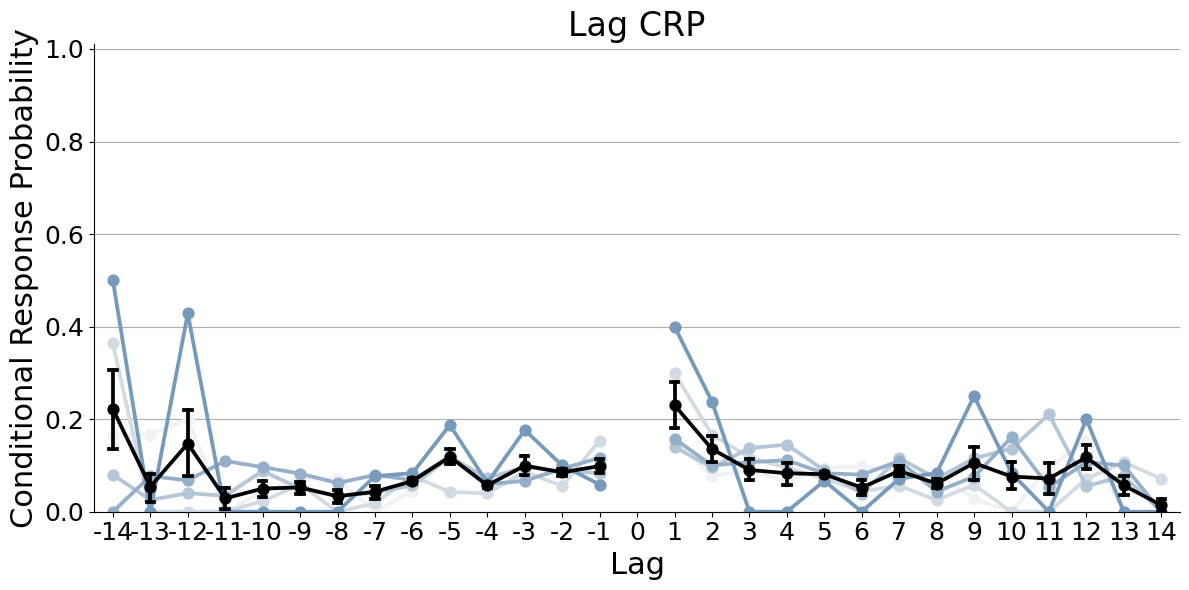

In [13]:
fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax = plt.gca()

from matplotlib.colors import ListedColormap

colors = sns.light_palette("#79B", len(sub_recall))
for i, sub in enumerate(sub_recall):
    sub_crp = crp_df.query('subject == @sub')
    sns.pointplot(data=sub_crp, x="lag", y="prob", 
                  color= colors[i], 
                  ax=ax,
                  linestyles="-")

crp = sns.pointplot(data=crp_df, x='lag', y='prob', ci=68,
                    color='k', capsize=.2, ax=ax)

ax.set_title('Lag CRP', fontsize=24)
ax.set_xlabel('Lag', fontsize=22)
ax.set_ylabel('Conditional Response Probability', fontsize=22)
ax.tick_params(labelsize=18)
plt.ylim([0,1.01])
ax.yaxis.grid()
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
# Temporal clustering score

temporal_clustering_df = compute_temporal_clustering(temporal_evs)
temporal_clustering_df

,subject,TC
0,LTP606,0.527796
1,LTP607,0.540844
3,LTP610,0.556093
4,LTP612,0.589527
2,LTP609,0.678305


                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      abs_error
No. Observations:      201          Method:                  ML       
No. Groups:            5            Scale:                   18.8462  
Min. group size:       5            Log-Likelihood:          -580.7783
Max. group size:       55           Converged:               Yes      
Mean group size:       40.2                                           
----------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------
Intercept                -23.933    3.536 -6.768 0.000 -30.864 -17.003
storepointtype[T.random]   0.026    0.616  0.043 0.966  -1.181   1.234
TC                        51.431    5.634  9.129 0.000  40.389  62.473
Recall_Probability        -4.179    2.922 -1.430 0.153  -9.907   1.548
Group Var              

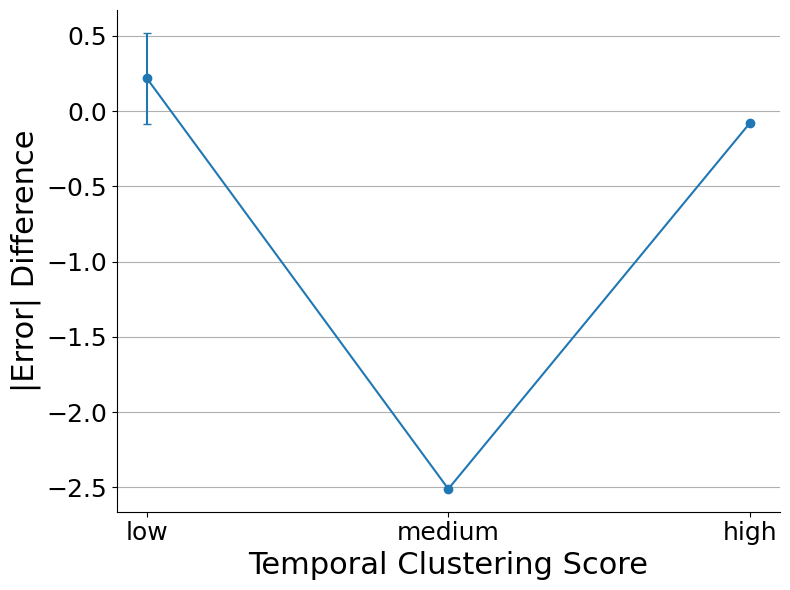

In [15]:
merged_df = get_mixed_model_fitted_error(temporal_evs, recall_by_sub)
plot_error_diff_vs_binned_cluster_score(merged_df)

## Encoding

In [16]:
REL_START, REL_STOP = 200, 3000
BUFFER_MS = 1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [17]:
df_idx = cml.get_data_index('ltp').query("experiment == 'ValueCourier'").copy()
if subjects is not None:
    df_idx = df_idx[df_idx['subject'].isin(subjects)]
subjects = sorted(df_idx.subject.unique())

a

In [18]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [19]:
def process_subject_stats(subject, exp, batch):
    sessions = cml.get_data_index('ltp').query(
        "experiment == @exp and subject == @subject"
    ).session.unique()

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        ret_evs = None
        delib_evs = None
        try:
            reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
            evs_all = reader.load('task_events')
            evs_all = evs_all[(evs_all['type']=='WORD') & (evs_all['eegoffset']>=0)]
            if evs_all.empty:
                continue

            for start in range(0, len(evs_all), batch):
                evs = evs_all.iloc[start:start+batch]
                rec_mask = evs['recalled'].to_numpy().astype(bool)

                eeg = reader.load_eeg(
                    evs, rel_start=-BUFFER_MS, rel_stop=REL_STOP + BUFFER_MS, clean='LCF'
                ).to_ptsa()

                eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg)
                mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)
                pwr = mw.filter(eeg).sel(time=slice(REL_START, REL_STOP)).mean(dim='time')

                p = pwr.transpose('event', 'channel', 'frequency').values
                chans = pwr['channel'].values

                for ci, ch in enumerate(chans):
                    if ch not in n1:
                        z = np.zeros(len(freq_vec), dtype=np.float64)
                        n1[ch] = 0; n0[ch] = 0
                        sum1[ch] = z.copy(); sum0[ch] = z.copy()
                        sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

                if rec_mask.any():
                    vals = p[rec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = rec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum1[ch]   += s[ci]
                        sumsq1[ch] += ss[ci]
                        n1[ch]     += cnt

                nrec_mask = ~rec_mask
                if nrec_mask.any():
                    vals = p[nrec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = nrec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum0[ch]   += s[ci]
                        sumsq0[ch] += ss[ci]
                        n0[ch]     += cnt

                del eeg, pwr, p
                gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    if not n1:
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [20]:
client = da.new_dask_client_slurm(
    job_name="encoding",
    memory_per_job="80GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="~/scratch",
    log_directory="log_directory"
)

Unique port for joycerose14 is 51609
{'dashboard_address': ':51609'}
To view the dashboard, run: 
`ssh -fN joycerose14@rhino2.psych.upenn.edu -L 8000:192.168.86.107:51609` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [21]:
futures = [client.submit(process_subject_stats, s, experiment, BATCH_EVENTS) for s in subjects]

In [22]:
subj_chan_t_list, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df_sub = fut.result()
        subj_chan_t_list.append(df_sub)
        n_done += 1
        sub = df_sub['subject'].iat[0] if not df_sub.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df_sub)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/5 :: LTP612 (rows=5888)
[DONE] 2/5 :: LTP607 (rows=5888)
[DONE] 3/5 :: LTP610 (rows=5888)
[DONE] 4/5 :: LTP609 (rows=5888)
[DONE] 5/5 :: LTP606 (rows=5888)


In [24]:
client.shutdown()

In [25]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [26]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [27]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

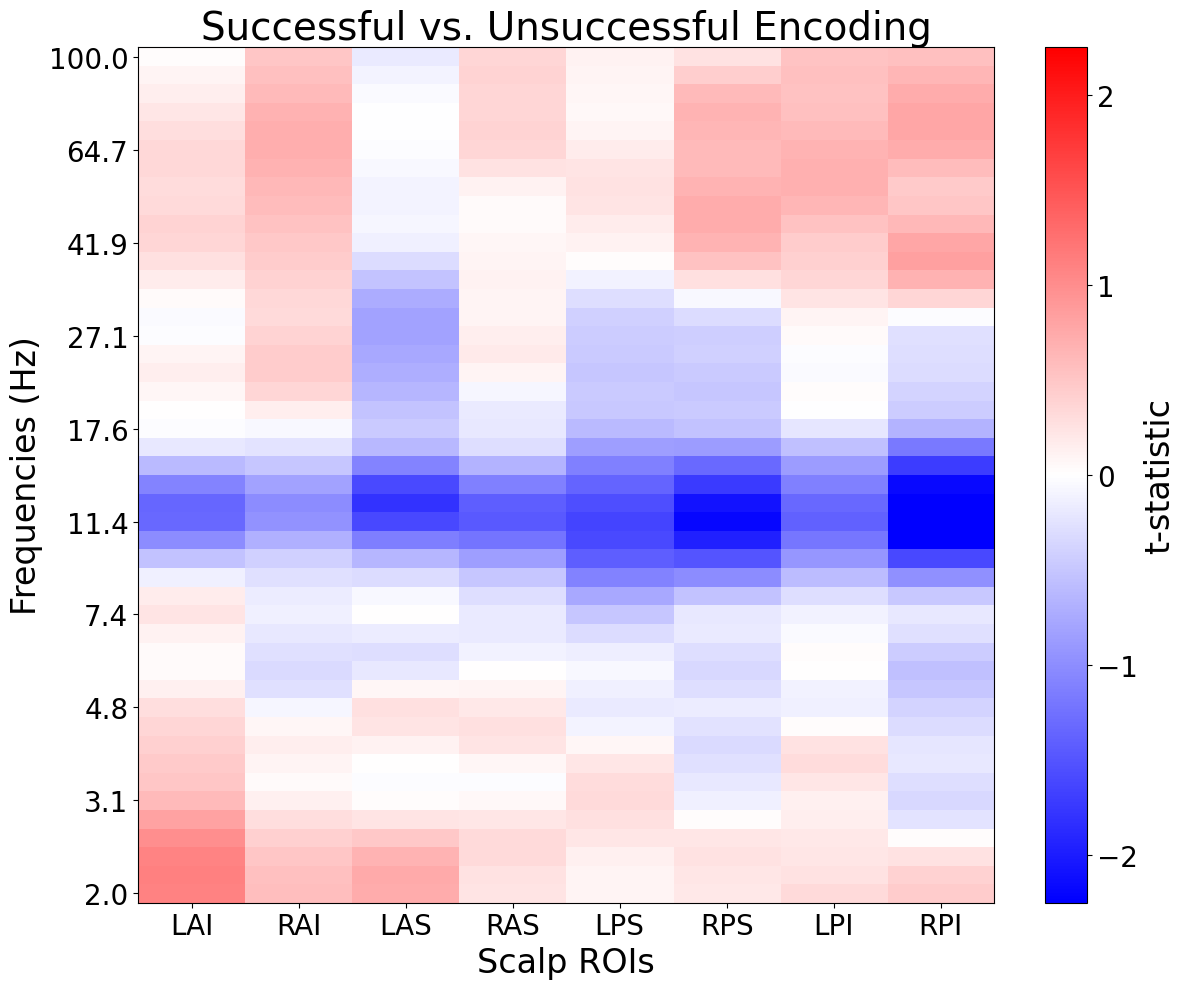

In [28]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful vs. Unsuccessful Encoding', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', size=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()